# Monetary Transmission in a HANK Model with Housing and Rental Sectors

Replication notebook for the **baseline model** of Albuquerque, Lazarowicz and
Lenney, *Monetary Transmission in a HANK Model with Housing and Rental Sectors*.
The paper is included in this repository as `MTHANKHOUSE.pdf`.

## What this notebook produces

| Notebook section | Output in the paper |
| --- | --- |
| Solve steady state and evaluate | Steady-state tenure shares and transition rates, Table 2 |
| Transitions and wealth distributions | Figures C.2 and C.1 |
| Income process and untargeted moments | Tables 2 and 4 |
| Jacobians | iMPCs by tenure, Panel (c) of Figure 6 |
| IRF matching | Figure 4, at the estimated parameters of Table 5 |
| Housing market response | Figure 5 |
| Elasticities | Figure 7 |
| Housing channel of monetary policy | Figure 6 |

Extensions and counterfactuals (Sections 4.4 and 4.5, Figures 9 and 10) are not
reproduced here. The blocks they need are kept in `HANK_Model/household.py` and
`HANK_Model/dynamics.py` under a `NOT USED BY Main.ipynb` banner.

## How to run

Run the cells in order. The two expensive steps, the steady state and the
household Jacobians, are cached under `data/`. The flags in the next cell detect
whether those caches exist: on a fresh clone they do not, so both steps are
computed and saved; on later runs they are loaded in seconds. Set either flag to
`1` by hand to force a recompute, for example after changing the calibration.

## Two code innovations

This model needs two extensions to the `sequence_jacobian` package, both
documented at the top of their modules:

- **`HANK_Model/fullgridclass.py`** lets the grid a policy is chosen from vary
  across the state space, which is required because the asset grid differs by
  housing tenure and the rental price grid differs between renters and owners.
  It also fixes a bug in `sequence_jacobian`'s shocked 2-D policy lottery.
- **`HANK_Model/behave_algo.py`** (`redform_jacob`) maps a rational-expectations
  Jacobian into the generalised Jacobian implied by sticky and extrapolative
  expectations. A standalone write-up of the method is at
  <https://s0840389.github.io/jamielenneyecon/>.

See `README.md` for both in more detail.

In [ ]:
import os
import sys
import pickle
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sequence_jacobian import create_model
from sequence_jacobian.blocks.stage_block import StageBlock
from sequence_jacobian.blocks.support.stages import ExogenousMaker, LogitChoice

import warnings
warnings.filterwarnings('ignore')

# The model modules live in HANK_Model/ and import each other by bare name, so
# that directory has to be on the path.
sys.path.append(os.path.abspath("HANK_Model"))

%load_ext autoreload
%autoreload 2

# ---------------------------------------------------------------------------
# Cached results
#
# The steady state and the household Jacobians are the two expensive steps, so
# they are cached under data/.  Each flag is set to 1 when its cache is missing
# (as on a fresh clone), which computes the object and saves it, and to 0 when
# the cache is present, which loads it.
#
# Set either flag to 1 by hand to force a recompute, for example after changing
# the calibration below. Steady state takes around 2 minutes to compute, and the 
#  Jacobian takes around 15 minutes on an Intel(R) Core(TM) Ultra 7 255H with 32 GB RAM.

# ---------------------------------------------------------------------------

ss_file = './data/ss0_eis1.pickle'
Jk_file = './data/Jk_eis1.pickle'

solvess = 1 
solveJK = 1 

print(f'solvess = {solvess}   (1 = solve the steady state and cache it, 0 = load the cache)')
print(f'solveJK = {solveJK}   (1 = compute the Jacobian and cache it, 0 = load the cache)')

solvess = 1   (1 = solve the steady state and cache it, 0 = load the cache)
solveJK = 1   (1 = compute the Jacobian and cache it, 0 = load the cache)


## Calibration and model set up

Parameters are split three ways, as in Section 3.5 of the paper: internally
estimated to match steady-state moments (Table 2), externally calibrated from
the literature and UK data (Table 3), and estimated by IRF matching (Table 5).

The dictionary below holds the first two groups plus starting values for the
third. The IRF-matched values themselves are applied later, in the IRF matching
section; the values set here are only initial guesses.

In [2]:
cali = {
        # household parameters
        'taste_shock': 0.2, # taste shock standard deviation
        'eis': 0.5, # CRRA = 1/eis
        'frisch':0.5, # frisch elasticity
        'beta': 0.985199,#0.98256198, # discount factor
        'borlim': 0.0, # borrowing limit for renters

        # income process
        'rho_z1': 0.98988099,  # persistence of AR process for idiosyncratic income
        'sd_z1': 0.10004893,  # standard deviation of AR process
        'n_z1': 5, # number of labor income prod gridpoints

        'rho_z2': 0.0837097,  # persistence of AR process for idiosyncratic income
        'sd_z2': 0.01,  # standard deviation of AR process
        'n_z2': 3, # number of labor income prod gridpoints
        'min_z': 0.284, # targeting 90-10

        # housing params
        'defaultcost': 5.0,
        'borwedge': 0.0125/4, # borrowing spread
        'pr_calvo': 0.25, # Calvo price setting
        'phy': 6.3*4, # house price to income ratio
        'Fsize': 2/3, # size of rental property
        'kappah':0.9, # loan to value
        'kappahLL':0.75, # loan to value landlords
        'kappay':  4.5*4, # loan to income
        'deltah': 0.113, # housing depreciation [ share of steady state rent price] chosen such that hmcost=deltah*np.exp(pr)/Fsize = 0.021 mentioned in the paper
        'etasell': 1.0, # probaility of selling house in period [1 if no selling frictions]
        'FixP': 0, #mortgage fixation period

        # firm parameters
        'alphah': 1.0,
        'mu': 1.06, # markup
        'Y': 1, # output
        'Z': 1, # productivity
        'NEss': 1.0, # steady state labour services

        # government
        'TransfAgg': 0.00, # aggregate transfers
        'r': 0.02/4,
        'Gguess': 0.25, # government spending guess [solved for in steady state]

        # grids and misc
        'n_a': 250, # number of gridpoints
        'n_h': 17,# number of transitions
        'MPC':0.0,    # Don't touch this. Need this to be zero to compute IMPCs

        # ss target params
        'phihs':0.349995838,
        'omegah': 1.100028623,
        'movecost': 0.05811327 ,#0.05184,
        'movecostLL':  0.59331288,#0.36288,
        'llcost' : 0.01036894-0.002, # utility cost of being landlord
        'pr': -2.0713242 # steady state rent price
}


# dyanmic parameters (inital guesses)
cali['kappaw']=(1-0.979*0.899)*(1-0.899)/0.899*(17.66/(17.66+10-1))
cali['kappa']=(1-1/(1.05)*0.926)*(1-0.926)/0.926*(17.66/(17.66+10-1)) # auclert MJMH
cali['phi']=1.5 # taylor rule
cali['phiy']=0.0 # weight on output gap
cali['gammatax']=0.1# tax elasticity
cali['rhom']=0.8 # monetary policy persistence

# dyanmic parameters: behavioral parameters
cali['deltaWK']= 0.77
cali['deltaWKph']= 0.77
cali['gammaWK']=-0.14
cali['gammaWKph']=-0.14



### Stage 1: exogenous productivity shock

Idiosyncratic labour productivity is the sum of a persistent and a transitory
AR(1) process, each discretised by Rouwenhorst and combined by Kronecker
product into 15 states (`mixedAR1` in `household.py`). Index 1 of the state
space is the productivity dimension.

In [3]:
# Index 1 of the state space is idiosyncratic labour productivity z.
prod_stage = ExogenousMaker(markov_name='z_markov', index=1, name='prod')

### Stage 2: tenure choice and rental contract

Two things happen at this stage.

First, `rent_calvo` draws whether the household's rental contract resets. With
probability `pr_calvo` a renter or landlord moves to the market spot rent,
otherwise they carry last period's nominal rent. This is what makes the
individual rental price `p_r,i` a household-level state, and it operates on
index 0, the housing transition dimension.

Second, `house_choice` is the discrete tenure choice of equation (1). Taste
shocks are Gumbel with scale `taste_shock`, so `LogitChoice` gives the closed
form transition probabilities of equation (2). The flow payoff of each of the
17 possible transitions, including the fixed costs `eta(h)` and the transitions
ruled out by borrowing constraints or default, comes from `util_l`.

In [4]:
%autoreload 2

from household import util_l

# Rental contract reset.  Operates on index 0, the housing transition, moving a
# renter or landlord into a 'starred' state at the market spot rent with
# probability pr_calvo.
rent_calvo = ExogenousMaker(markov_name='h_markov', index=0, name='rent_calvo')

# Discrete tenure choice.  Gumbel taste shocks with scale taste_shock give the
# logit transition probabilities of equation (2); util_l supplies the flow
# payoff of each of the 17 transitions.
house_choice_stage = LogitChoice(value='V', backward=['Va'], index=0, name='house_choice',
                                 taste_shock_scale='taste_shock', f=util_l)

### Stage 3: consumption and saving

Consumption and saving conditional on the tenure decision, solved by DC-EGM:
the endogenous grid point method of Carroll (2006) with the upper envelope step
of Iskhakov et al. (2017). The upper envelope is needed because the discrete
tenure choice makes the value function non-concave, so the Euler equation can
have several solutions (Section 3.5).

This stage uses `Continuous2DFullGrid` rather than `sequence_jacobian`'s
`Continuous2D`, for two reasons set out in the module docstring of
`fullgridclass.py`:

1. There are **two** endogenous continuous choices, savings `a` and the rental
   price `pri` carried into next period.
2. Both are chosen from grids that **vary across the state space**. The asset
   grid differs by housing tenure because borrowing capacity does (Table C.1),
   and the rental price grid is degenerate for owner-occupiers who pay no rent.
   Stock `sequence_jacobian` assumes one grid shared by the whole state space.

In [5]:
%autoreload 2

from household import make_grids, labor_income, hh_init, prices_baseline
from household import dcegm, housingDemand, assetDemand, labor_supply

from fullgridclass import Continuous2DFullGrid

# Consumption-saving stage.  Two endogenous policies, savings 'a' and the rental
# price 'pri' carried into next period, each chosen from a state-dependent grid
# (hence FullGrid rather than sequence_jacobian's Continuous2D).
consav_stage = Continuous2DFullGrid(backward=['V', 'Va'], policy=['a', 'pri'], f=dcegm,
                                    name='consav',
                                    hetoutputs=[labor_supply, housingDemand, assetDemand])

## Solve the steady state and evaluate

Assembles the four stages into the household block, solves for the steady
state, and reports the tenure shares and transition rates that the internally
estimated parameters of Table 2 target.

To re-run the internal calibration rather than use the stored parameters, add
the `SSsolve` block from `steadystate.py`, which returns the distance between
the model's moments and their targets.

In [6]:
%autoreload 2

from steadystate import firmSS, housingSS, TaxTransfss, market_clearingSS, SSparams, pricesSS

# Assemble the four stages into the household block.
hh = StageBlock([prod_stage, rent_calvo, house_choice_stage, consav_stage], name='hh',
                backward_init=hh_init, hetinputs=[make_grids, prices_baseline, labor_income])

if solvess == 1:

    blocks_ss = [hh, firmSS, housingSS, TaxTransfss, market_clearingSS, SSparams, pricesSS]

    hank_ss = create_model(blocks_ss, name="HANK SS")
    ss0 = hank_ss.steady_state(cali)

    pickle.dump(ss0, open(ss_file, 'wb'))

else:

    ss0 = pickle.load(open(ss_file, 'rb'))


# Steady-state moments targeted by the internally estimated parameters, Table 2.
print('Total Saving: ' + str(np.round(ss0['A'], 3)) + " / " + str(np.round(ss0['A'] / 4, 3)) + '(ann)')
print('Renter Share: ' + str(np.round(ss0['HR'], 3)))
print('Flat Share: ' + str(np.round(ss0['HOOF'], 3)))
print('House Share: ' + str(np.round(ss0['HOO'], 3)))
print('Landlord Share: ' + str(np.round(ss0['HLL'] + ss0['HLL2'], 3)))
print('Landlord Share2: ' + str(np.round(ss0['HLL2'], 3)))
print('Own Exit Rate:' + str(np.round(ss0['OWNEXIT'] / (1 - ss0['HR']) * 400, 2)) + '%')
print('Landlord exit rate:' + str(np.round(ss0['LLEXIT'] / (ss0['HLL'] + ss0['HLL2']) * 400, 2)) + '%')

Total Saving: 2.528 / 0.632(ann)
Renter Share: 0.327
Flat Share: 0.096
House Share: 0.522
Landlord Share: 0.055
Landlord Share2: 0.008
Own Exit Rate:1.17%
Landlord exit rate:7.06%


### Transitions and wealth distributions

Reproduces **Figure C.2** (probability of each tenure transition by starting
wealth, at five points of the income distribution) and **Figure C.1** (the
steady-state asset distribution by tenure).

The transition probabilities come straight out of the logit stage's law of
motion, `P[h_from, h_to, z, a, pr]`.

Text(0.5, 1.0, '(d): LandLords')

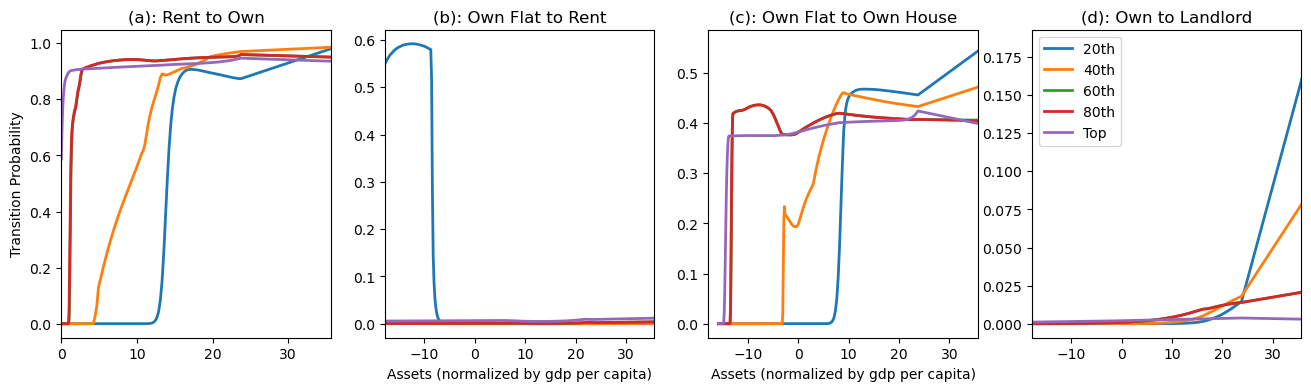

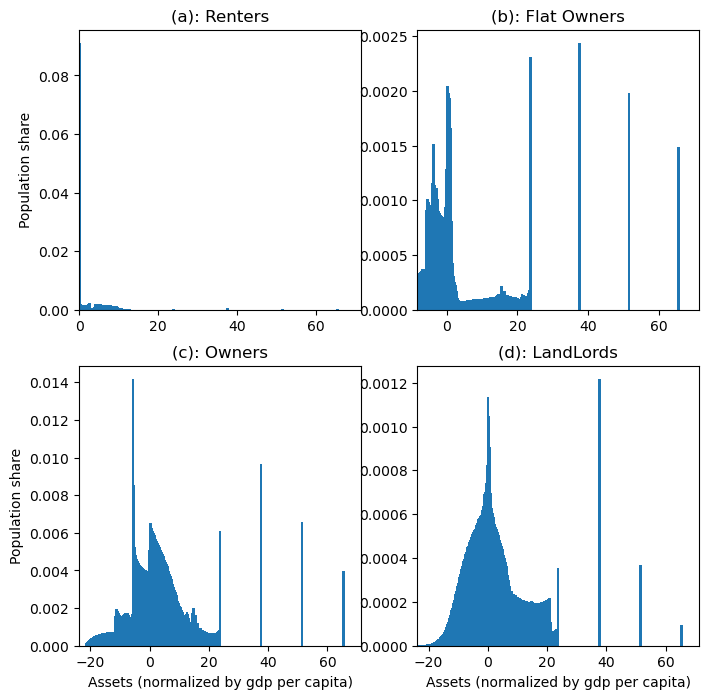

In [7]:
# The four tenure-specific asset grids of Table C.1.
agridR = ss0.internals['hh']['a_grid_r']
agridO=ss0.internals['hh']['a_grid_o']
agridLL=ss0.internals['hh']['a_grid_ll']
agridOF=ss0.internals['hh']['a_grid_of']

fig_trans,ax=plt.subplots(1,4,figsize=(16,4))

# Figure C.2: transition probabilities out of the logit stage's law of motion,
# P[h_to, h_from, z, a, pr], plotted at five points of the income distribution.
ax[0].plot(agridR,np.swapaxes(ss0.internals['hh']['house_choice']['law_of_motion'].P[2,14,[3,7,9,11,14],:,0],0,1), linewidth=2, linestyle = '-')
ax[0].set_xlim(0,np.exp(ss0['ph'])*1.5)
ax[0].set_ylabel('Transition Probability')
ax[0].set_title('(a): Rent to Own')

ax[1].plot(agridO,np.swapaxes(ss0.internals['hh']['house_choice']['law_of_motion'].P[10,9,[3,7,9,11,14],:,0],0,1), linewidth=2, linestyle = '-')
ax[1].set_xlabel('Assets (normalized by gdp per capita)')
ax[1].set_xlim(-0.75*np.exp(ss0['ph']),np.exp(ss0['ph'])*1.5)
ax[1].set_title('(b): Own Flat to Rent')

ax[2].plot(agridOF,np.swapaxes(ss0.internals['hh']['house_choice']['law_of_motion'].P[8,9,[3,7,9,11,14],:,0],0,1), linewidth=2, linestyle = '-')
ax[2].set_xlabel('Assets (normalized by gdp per capita)')
ax[2].set_xlim(-0.75*np.exp(ss0['ph']),np.exp(ss0['ph'])*1.5)
ax[2].set_title('(c): Own Flat to Own House')

ax[3].plot(agridO,np.swapaxes(ss0.internals['hh']['house_choice']['law_of_motion'].P[4,0,[3,7,9,11,14],:,0],0,1), linewidth=2, linestyle = '-')
ax[3].set_xlim(-0.75*np.exp(ss0['ph']),np.exp(ss0['ph'])*1.5)
ax[3].legend(['20th','40th','60th','80th','Top'])
ax[3].set_title('(d): Own to Landlord')


# Figure C.1: steady-state asset distribution by tenure.  Sum the distribution
# over the transitions that share a destination tenure, and over z and pri.

figdist, ax = plt.subplots(2,2,figsize=(8,8))

rdist=np.sum(ss0.internals['hh']['consav']['D'][[3,10,14],:,:,:],axis=(0,1,3))
odist=np.sum(ss0.internals['hh']['consav']['D'][[0,5,8],:,:,:],axis=(0,1,3))
lldist=np.sum(ss0.internals['hh']['consav']['D'][[4,6,12,11,13,15,16],:,:,:],axis=(0,1,3))
ofdist=np.sum(ss0.internals['hh']['consav']['D'][[2,7,9],:,:,:],axis=(0,1,3))

ax[0,0].bar(agridR,rdist)
ax[0,0].set_xlim(0,np.exp(ss0['ph'])*3)
ax[0,0].set_title('(a): Renters')
ax[0,0].set_ylabel('Population share')

ax[0,1].bar(agridOF,ofdist)
ax[0,1].set_xlim(-np.exp(ss0['ph']*ss0['Fsize']),np.exp(ss0['ph'])*3)
ax[0,1].set_title('(b): Flat Owners')

ax[1,0].bar(agridO,odist)
ax[1,0].set_xlabel('Assets (normalized by gdp per capita)')
ax[1,0].set_xlim(-np.exp(ss0['ph']),np.exp(ss0['ph'])*3)
ax[1,0].set_title('(c): Owners')
ax[1,0].set_ylabel('Population share')

ax[1,1].bar(agridLL,lldist)
ax[1,1].set_xlabel('Assets (normalized by gdp per capita)')
ax[1,1].set_xlim(-np.exp(ss0['ph']),np.exp(ss0['ph'])*3)
ax[1,1].set_title('(d): LandLords')


### Income process and untargeted moments

Reproduces the income moments of **Table 2** (mean, cross-sectional standard
deviation, one-year and five-year earnings-change standard deviations, and the
90-10 ratio) and the untargeted moments of **Table 4**:

1. Housing net worth over total net worth
2. Wealth share of the top 10 per cent
3. Share of homeowners who borrow
4. Share of landlords who borrow
5. Average rent to average renter income

In [8]:
%autoreload 2

from aux_fns import weighted_percentile, income_variance_n_quarters

# variance of income processes

muz=np.sum(ss0.internals['hh']['z_grid']*ss0.internals['hh']['z_dist'])*np.exp(ss0['w'])*np.exp(ss0['hours'])
sdz=np.sqrt(np.sum(ss0.internals['hh']['z_grid']**2*ss0.internals['hh']['z_dist']) -np.sum(ss0.internals['hh']['z_grid']*ss0.internals['hh']['z_dist'])**2)

vz4=income_variance_n_quarters(ss0.internals['hh']['z_grid']*np.exp(ss0['w'])*np.exp(ss0['hours']), ss0.internals['hh']['z_dist'], ss0.internals['hh']['z_markov'], 4)
vz20=income_variance_n_quarters(ss0.internals['hh']['z_grid']*np.exp(ss0['w'])*np.exp(ss0['hours']), ss0.internals['hh']['z_dist'], ss0.internals['hh']['z_markov'], 20)

# compute 90-10 income ratio
p10_income = weighted_percentile(ss0.internals['hh']['z_grid']*np.exp(ss0['w'])*np.exp(ss0['hours']), ss0.internals['hh']['z_dist'], 10)
p90_income = weighted_percentile(ss0.internals['hh']['z_grid']*np.exp(ss0['w'])*np.exp(ss0['hours']), ss0.internals['hh']['z_dist'], 90)
income_ratio_90_10 = p90_income / p10_income

tbl_income=pd.DataFrame({'1: mu':[muz],'2: sd':[sdz],'3: sd4':[np.sqrt(vz4)],'4: sd20':[np.sqrt(vz20)],'5: p90/p10':[income_ratio_90_10]})


print(tbl_income)

afull=ss0.internals['hh']['a_grid_full']

# Table 4, moment 1: housing wealth to financial net worth
hnw=ss0['Hbar']*np.exp(ss0['ph'])/(ss0['A'])

# Table 4, moment 2: wealth share of the top 10 per cent
D=ss0.internals['hh']['consav']['D']
Dlong=D.flatten()
along=afull.flatten()

hfull=np.zeros_like(afull)
hfull[[0,5,8]]=1*np.exp(ss0['ph'])
hfull[[2,7,9]]=np.exp(ss0['ph']*ss0['Fsize'])
hfull[[4,6,12,15]]=np.exp(ss0['ph'])*(1+ss0['Fsize'])
hfull[[11,13,16]]=np.exp(ss0['ph'])*(1+2*ss0['Fsize'])
totwfull=hfull+afull

totwlong=totwfull.flatten()

p90=weighted_percentile(totwlong,Dlong,90)
nfw_shr90=np.sum(D*(totwfull>=p90)*totwfull)/np.sum(D*totwfull)

# Table 4, moment 3: share of homeowners who borrow
ho_bor=np.sum(D[[0,2,4,5,6,7,8,9,11,12,13]]*(afull[[0,2,4,5,6,7,8,9,11,12,13]]<0))/np.sum(D[[0,2,4,5,6,7,8,9,11,12,13]])

# Table 4, moment 4: share of landlords who borrow
ll_bor=np.sum(D[[4,6,11,12,13,15,16]]*(afull[[4,6,11,12,13,15,16]]<0))/np.sum(D[[4,6,11,12,13,15,16]])

# Table 4, moment 5: average rent to average renter disposable income
disinc=ss0.internals['hh']['disinc']
avg_pr_y=np.exp(ss0['pr'])/(np.sum(disinc[[1,3,10]]*D[[1,3,10]])/np.sum(D[[1,3,10]]))


tbl_untargeted=pd.DataFrame({'1: hnw/fnw':[hnw],'2: Wp90':[nfw_shr90],'3: seg_shr':[ho_bor],
                           '4: BTL_shr':[ll_bor],'5: pr/y':[avg_pr_y]})

print(tbl_untargeted)

      1: mu    2: sd    3: sd4   4: sd20  5: p90/p10
0  0.943396  0.72725  0.220056  0.503401    4.655814
   1: hnw/fnw   2: Wp90  3: seg_shr  4: BTL_shr   5: pr/y
0    8.077112  0.312128    0.537824    0.486933  0.284075


## Jacobians

Computes the household block's sequence-space Jacobians `Jk` for shocks to the
real rate, wage, house price, rental price, hours, a lump-sum transfer,
dividends, taxes and inflation. This is a standard `sequence_jacobian` call.

It then derives the **fake news matrices** `Fk` from `Jk`. These are needed
because the behavioural expectations of Section 3.3 are imposed by transforming
`F`, not `J`: `F[t, s]` isolates the *new information* arriving at each date,
which is exactly what the sticky and extrapolative channels act on, so the
transformation collapses to a single pass over `F` (see `behave_algo.py`).

`sequence_jacobian` builds `F` internally on the way to `J` but returns only
`J`. Rather than reaching into its Jacobian machinery to intercept `F`, we
invert the accumulation `J[t, s] = J[t-1, s-1] + F[t, s]`, which is a single
differencing pass and exact to machine precision. That keeps the model solvable
with the standard, unmodified `sequence_jacobian` API.

The rest of the cell computes intertemporal MPCs from the transfer column of
the Jacobian and splits them by tenure, giving **Panel (c) of Figure 6**. The
`MPC` input is zero in steady state precisely so this column is available.

In [ ]:
from behave_algo import JtoFdict

# Truncation horizon for the sequence-space solution.
T=400

if solveJK==1:

    # Standard sequence_jacobian call; no patching of the package required.
    Jk = hh.jacobian(ss0, ['r', 'w','ph','pr','hours','MPC','Div','Tax','pi'], T=T)

    pickle.dump(Jk, open(Jk_file, 'wb'))

else:

    Jk = pickle.load(open(Jk_file, 'rb'))


# Fake news matrices, recovered from the Jacobian by inverting the accumulation
# J[t,s] = J[t-1,s-1] + F[t,s].  Fk is what redform_jacob needs to impose the
# behavioural expectations; it is cheap to derive, so it is not cached.
Fk = JtoFdict(Jk)


# Intertemporal MPCs: the response of consumption to a one-off lump-sum
# transfer, i.e. the first column of the Jacobian with respect to MPC.

quarterly_MPC = Jk['C']['MPC'].T[0]

# By tenure.  Each group's average consumption is the group total over the count
# of households in it, so the MPC has to be differenced in that ratio.
quarterly_MPC_rent=(Jk['CRENT']['MPC'].T[0]+ss0['CRENT'])/(Jk['CRENTWGT']['MPC'].T[0]+ss0['CRENTWGT'])-ss0['CRENT']/ss0['CRENTWGT']
quarterly_MPC_own=(Jk['COO']['MPC'].T[0]+ss0['COO'])/(Jk['COOWGT']['MPC'].T[0]+ss0['COOWGT'])-ss0['COO']/ss0['COOWGT']
quarterly_MPC_mort=(Jk['CMORT']['MPC'].T[0]+ss0['CMORT'])/(Jk['CMORTWGT']['MPC'].T[0]+ss0['CMORTWGT'])-ss0['CMORT']/ss0['CMORTWGT']
quarterly_MPC_landlord=(Jk['CLL']['MPC'].T[0]+ss0['CLL'])/(Jk['CLLWGT']['MPC'].T[0]+ss0['CLLWGT'])-ss0['CLL']/ss0['CLLWGT']


annual_MPC=np.array([np.sum(quarterly_MPC[0:4]),np.sum(quarterly_MPC[4:8]),np.sum(quarterly_MPC[8:12]),np.sum(quarterly_MPC[12:16]),np.sum(quarterly_MPC[16:20])])
annual_MPC_rent = np.array([np.sum(quarterly_MPC_rent[0:4]),np.sum(quarterly_MPC_rent[4:8]),np.sum(quarterly_MPC_rent[8:12]),np.sum(quarterly_MPC_rent[12:16]),np.sum(quarterly_MPC_rent[16:20])])
annual_MPC_own = np.array([np.sum(quarterly_MPC_own[0:4]),np.sum(quarterly_MPC_own[4:8]),np.sum(quarterly_MPC_own[8:12]),np.sum(quarterly_MPC_own[12:16]),np.sum(quarterly_MPC_own[16:20])])
annual_MPC_mort = np.array([np.sum(quarterly_MPC_mort[0:4]),np.sum(quarterly_MPC_mort[4:8]),np.sum(quarterly_MPC_mort[8:12]),np.sum(quarterly_MPC_mort[12:16]),np.sum(quarterly_MPC_mort[16:20])])
annual_MPC_landlord = np.array([np.sum(quarterly_MPC_landlord[0:4]),np.sum(quarterly_MPC_landlord[4:8]),np.sum(quarterly_MPC_landlord[8:12]),np.sum(quarterly_MPC_landlord[12:16]),np.sum(quarterly_MPC_landlord[16:20])])


# Panel (c) of Figure 6.
fgMPC, ax = plt.subplots(1,1,figsize=(6,4))

ax.plot([0,4,8,12,16],annual_MPC, label = 'Average', color = 'red')
ax.plot([0,4,8,12,16],annual_MPC_rent, label = 'Renters', color = 'lightblue', linestyle = 'dashdot')
ax.plot([0,4,8,12,16],annual_MPC_own, label = 'Owners', color = 'lightblue', linestyle = 'dotted')
ax.plot([0,4,8,12,16],annual_MPC_mort, label = 'Mortgaged', color = 'lightblue', linestyle = 'dashed')
ax.plot([0,4,8,12,16],annual_MPC_landlord, label = 'Landlords', color = 'lightblue', linestyle = 'solid')


#Bunn, P., Le Roux, J., Reinold, K., & Surico, P. (2018). The consumption response to positive and negative income shocks. Journal of Monetary Economics, 96, 1-15.
nmg_points = np.array([0.14, np.nan, 0.64])
ax.scatter(np.zeros_like(nmg_points), nmg_points, label='Bunn et al. 2018', color='orange')
plt.errorbar(0,0.5,np.array([0.5-0.14,0.64-0.5])[:,np.newaxis],label='',fmt='',color='orange')


ax.scatter( [0,4,8,12,16],np.array([0.5056845, 0.1759051, 0.1035106, 0.0444222, 0.0336616]), label ='Fagereng et al. 2021', color = 'k')


ax.legend()
ax.set_xticks([0,4,8,12,16], [ '0' , '1', '2', '3', '4'])
ax.set_xlabel('Years')

tbl_mpc=pd.DataFrame({'1: NMG':[0.273],'2: Fagereng (2021)':[0.505],'3: Model':annual_MPC[0]})
print(tbl_mpc)

## Dynamics

### IRF matching

Closes the model with the aggregate blocks of `dynamics.py` and solves for the
response to a monetary policy shock, at the parameters estimated by the
minimum-distance procedure of Section 3.6, equation (14).

`Etype` selects the expectations process (appendix C.2):

| `Etype` | Process | Parameters |
| --- | --- | --- |
| 1 | Rational expectations | none |
| 2 | Sticky expectations | `delta` |
| 5 | Sticky and extrapolative, common to all prices | `delta`, `gamma` |
| 6 | Sticky and extrapolative, separate house price parameters | `delta`, `delta_ph`, `gamma`, `gamma_ph` |

The baseline is `Etype = 6`, which is what allows the model to match the large
hump-shaped fall in house prices jointly with a flat nominal rental price.

`x0` below holds the estimated parameters of **Table 5**. Re-running the
estimation means minimising `irfloss` from `aux_fns.py` over `x0`, which takes
several hours, so the solution is hard-coded here.

In [ ]:
%autoreload 2

from scipy.stats import norm

from dynamics import mkt_clearing, monetary, fisher, firm, fiscal, wagepc, nkpc, rentindexB, cpiindex

# irfloss (also in aux_fns) is the scalar objective for re-estimating x0
from aux_fns import dynIRFs

# ---------------------------------------------------------------------------
# Set up the general equilibrium model
# ---------------------------------------------------------------------------

exogenous = ['epsr', 'Z', 'epsH']

unknowns = ['r', 'w', 'Y', 'Tax', 'pr', 'ph', 'rentindex']
targets = ['asset_mkt', 'fisher_res', 'realwage_res', 'Tax_res', 'rental_mkt', 'housing_mkt',
           'rentindex_res']

blocks = [hh, firm, fisher, monetary, fiscal, mkt_clearing, wagepc, nkpc, rentindexB, cpiindex]

dynmod = create_model(blocks, name="LL HANK")

# Horizon plotted in the figures, and the variables whose IRFs we keep.
irfT = 12
iprlist = ['C', 'pr', 'ph', 'w', 'Y', 'rentindex', 'Tax', 'r', 'hours', 'Div', 'HSV', 'pi',
           'HR', 'HLL', 'piw', 'HLL2', 'HA_com', 'HD', 'goods_mkt', 'pi_cpi']

# Monetary policy shock: 25bp on the quarterly nominal rate on impact, which is
# 1 p.p. annualised, matching the normalisation of the empirical IRFs.
epsr = np.arange(T) * 0.0
epsr[0] = 0.0025

# ---------------------------------------------------------------------------
# Expectations process and estimated parameters
# ---------------------------------------------------------------------------

# 1: rational expectations
# 2: sticky
# 5: sticky and extrapolative, common parameters for all prices
# 6: sticky and extrapolative, separate house price parameters  <-- baseline
Etype = 6

# Parameters estimated by IRF matching, reported in Table 5.  In order:
#   kappa, kappaw, phi, gammatax, rhom, phiy,
#   price update probability, house price update probability,
#   price extrapolation gamma, house price extrapolation gamma_ph
#
# Note that x0[6] and x0[7] are update probabilities 1 / (1 + delta); dynIRFs
# converts them to delta.  To re-estimate, minimise aux_fns.irfloss over x0
# (several hours).
x0 = [1.25558606e-02,  3.25228527e-03,  1.10775122e+00,  1.16828197e-01,
      8.70984816e-01,  1.06129202e-07,  8.79774811e-01,  6.25306862e-01,
      -4.09028997e-01, 8.96925243e-02]

# ---------------------------------------------------------------------------
# Empirical IRFs to match (Section 2) and their weighting matrix
# ---------------------------------------------------------------------------

irftarget = pd.read_csv('./data/reirf_match_BMT.csv', header=None).to_numpy()

irfW = pd.read_csv('./data/wmatrix_match_BMT.csv', header=None).to_numpy()

# Standard errors of the empirical IRFs, for the confidence bands in Figure 4.
sdsIRF = np.reshape(1 / np.diag((irfW) ** 0.5), (12, 5), order='F')

# ---------------------------------------------------------------------------
# Solve
# ---------------------------------------------------------------------------

modssin = deepcopy(ss0)
hhJkin = deepcopy(Jk)
hhFkin = deepcopy(Fk)

# hhJk is the behavioural household Jacobian actually used by the solution;
# Jk remains the rational-expectations benchmark, used for comparison later.
irflossV, modirfs, modss, Gmatched, hhJk = dynIRFs(x0, modssin, hhJkin, hhFkin, dynmod, irftarget,
                                                   irfW, unknowns, targets, exogenous, T, Etype)

# General equilibrium IRFs to the monetary policy shock.
IPRs_matched = {}

for i in iprlist:
    try:
        IPRs_matched[i] = Gmatched[i]['epsr'] @ epsr
    except:
        pass

In [ ]:
# Walras's law check: the goods market should clear given that all other
# markets do, so this residual should be numerically zero.

fgw,ax=plt.subplots(1,1,figsize=(4,4))

ax.plot(IPRs_matched['goods_mkt'])
ax.set_title('Walras Law')

# Figure 4, panels (a) to (c): model against the empirical SVAR responses, with
# 68 and 90 per cent confidence bands.

fg_irfcomp1, ax=plt.subplots(1,3,figsize=(12,4))

ax[0].plot(irftarget[:,0],label='Data',color='black')
ax[0].plot(modirfs[:,0],label='Model',color='red')
ax[0].fill_between(range(sdsIRF.shape[0]),irftarget[:,0]+sdsIRF[:,0],irftarget[:,0]-sdsIRF[:,0],alpha=0.3,color='grey')
ax[0].fill_between(range(sdsIRF.shape[0]),irftarget[:,0]+sdsIRF[:,0]*norm.ppf(0.95),irftarget[:,0]-sdsIRF[:,0]*norm.ppf(0.95),alpha=0.17,color='grey')

ax[0].axhline(0, color='black',linewidth=0.5)
ax[0].set_title('(a): Interest Rate (pp)')
ax[0].set_xlim(0,irfT-1)

ax[1].plot(irftarget[:,1],label='Data',color='black')
ax[1].plot(modirfs[:,1],label='Model',color='red')
ax[1].fill_between(range(sdsIRF.shape[0]),irftarget[:,1]+sdsIRF[:,1],irftarget[:,1]-sdsIRF[:,1],alpha=0.3,color='grey')
ax[1].fill_between(range(sdsIRF.shape[0]),irftarget[:,1]+sdsIRF[:,1]*norm.ppf(0.95),irftarget[:,1]-sdsIRF[:,1]*norm.ppf(0.95),alpha=0.17,color='grey')
ax[1].axhline(0, color='black',linewidth=0.5)
ax[1].set_title('(b): Output (pct)')
ax[1].set_xlabel('Quarters')
ax[1].set_xlim(0,irfT-1)


ax[2].plot(irftarget[:,2],label='Data',color='black')
ax[2].plot(modirfs[:,2],label='Model',color='red')
ax[2].fill_between(range(sdsIRF.shape[0]),irftarget[:,2]+sdsIRF[:,2],irftarget[:,2]-sdsIRF[:,2],alpha=0.3,color='grey')
ax[2].fill_between(range(sdsIRF.shape[0]),irftarget[:,2]+sdsIRF[:,2]*norm.ppf(0.95),irftarget[:,2]-sdsIRF[:,2]*norm.ppf(0.95),alpha=0.17,color='grey')
ax[2].axhline(0, color='black',linewidth=0.5)
ax[2].set_title('(c): Price Level Excl. Rent (pct)')
ax[2].legend()
ax[2].set_xlim(0,irfT-1)


# Figure 4, panels (d) and (e).  House prices and rents are matched in nominal
# terms; the dashed line subtracts cumulated inflation to give the real path.

fg_irfcomp2, ax=plt.subplots(1,2,figsize=(8,4))

ax[0].plot(irftarget[:,3],color='black')
ax[0].plot(modirfs[:,3],color='red')
ax[0].fill_between(range(sdsIRF.shape[0]),irftarget[:,3]+sdsIRF[:,3],irftarget[:,3]-sdsIRF[:,3],alpha=0.3,color='grey')
ax[0].fill_between(range(sdsIRF.shape[0]),irftarget[:,3]+sdsIRF[:,3]*norm.ppf(0.95),irftarget[:,3]-sdsIRF[:,3]*norm.ppf(0.95),alpha=0.17,color='grey')
ax[0].plot(modirfs[:,3]-modirfs[:,2],color='red',linestyle='--',label='real')
ax[0].axhline(0, color='black',linewidth=0.5)
ax[0].set_title('(d): House Price')
ax[0].set_xlim(0,irfT-1)
ax[0].set_xlabel('Quarters')

ax[1].plot(irftarget[:,4],color='black',label='Data')
ax[1].plot(modirfs[:,4],color='red',label='Model')
ax[1].fill_between(range(sdsIRF.shape[0]),irftarget[:,4]+sdsIRF[:,4],irftarget[:,4]-sdsIRF[:,4],alpha=0.3,color='grey')
ax[1].fill_between(range(sdsIRF.shape[0]),irftarget[:,4]+sdsIRF[:,4]*norm.ppf(0.95),irftarget[:,4]-sdsIRF[:,4]*norm.ppf(0.95),alpha=0.17,color='grey')
ax[1].plot(modirfs[:,4]-modirfs[:,2],color='red',label='Model, real',linestyle='--')
ax[1].axhline(0, color='black',linewidth=0.5)
ax[1].set_title('(e): Rent Price')
ax[1].set_xlim(0,irfT-1)
ax[1].legend()
ax[1].set_xlabel('Quarters')

# Figure D.1: housing market activity.  Consistent with the SVAR evidence of
# Figure 3, sales fall persistently and the rental share rises temporarily.

fg_othhousing,ax =plt.subplots(1,2,figsize=(8,4))

# rental share

ax[0].plot(IPRs_matched['HR']/ss0['HR']*100,color='red')
ax[0].set_xlim([0,irfT])
ax[0].set_title('(a): Rental Share (pp)')
ax[0].set_xlabel('Quarters')
ax[0].axhline(0, color='black',linewidth=0.5)

# sales volumes

ax[1].plot(IPRs_matched['HSV']/ss0['HSV']*100,color='red')
ax[1].set_xlim([0,irfT])
ax[1].set_title('(b): Sales Volume (pct)')
ax[1].set_xlabel('Quarters')
ax[1].axhline(0, color='black',linewidth=0.5)



## Analysis

### Housing market response: partial equilibrium decomposition

Reproduces **Figure 5**. Panels (a) and (c) show the partial equilibrium
response of the rental and housing markets to the real rate path implied by the
monetary policy shock, holding all other prices fixed. That response cannot be
an equilibrium: it leaves excess demand for rental units and excess supply of
housing.

Panels (b) and (d) decompose the general equilibrium price movements that close
those gaps, so the bars sum to zero in each period. The result is that house
prices do nearly all the work.

In [ ]:
# Figure 5.  The partial equilibrium responses in panels (a) and (c) are the
# household Jacobian with respect to the real rate, applied to the general
# equilibrium real rate path; all other prices are held fixed.

fig_houserResp_match,ax = plt.subplots(2,2,figsize=(13,9))

# Panel (a): partial equilibrium rental demand and landlord supply

ax[0,0].plot(hhJk['HR']['r']@IPRs_matched['r']/ss0['HR']*100,label='Rental Demand',linestyle='--',color='purple')
ax[0,0].plot((hhJk['HLL']['r']+2*hhJk['HLL2']['r'])@IPRs_matched['r']/ss0['HR']*100,label='Landlord Supply',linestyle='--',color='brown')
ax[0,0].plot((hhJk['HR']['r']-hhJk['HLL']['r']-2*hhJk['HLL2']['r'])@IPRs_matched['r']/ss0['HR']*100,label='Net Rental Market',color='darkblue')

ax[0,0].set_xlim([0,irfT])
ax[0,0].set_ylim([-4.6, 4.6])
ax[0,0].set_yticks(range(-4,5))
ax[0,0].legend()
ax[0,0].set_title('(a): Demand/Supply Reponse to Real Rate')
ax[0,0].set_xlabel('Quarters')
ax[0,0].set_ylabel('Percentage of Renter Share')
ax[0,0].axhline(0, color='black',linewidth=0.5)

# Panel (b): general equilibrium.  Contribution of each price to closing the
# rental market gap traced out in panel (a); the bars sum to zero each period.

tt=np.arange(0,T)

yyoldminus=0*tt[0:irfT]
yyoldplus=0*yyoldminus

bcolor=['darkblue','fuchsia','cyan','orange']
ledge_label=['Interest Rate','Rent Price','House Price','Income']

# Calculate components
yy_r = (100*(hhJk['HR']['r']-hhJk['HLL']['r']-2*hhJk['HLL2']['r'])@IPRs_matched['r']/ss0['HR'])
yy_rent = (100*(hhJk['HR']['pr']-hhJk['HLL']['pr']-2*hhJk['HLL2']['pr'])@IPRs_matched['pr']/ss0['HR'])+(100*(hhJk['HR']['pi']-hhJk['HLL']['pi']-2*hhJk['HLL2']['pi'])@IPRs_matched['pi']/ss0['HR'])
yy_hp = (100*(hhJk['HR']['ph']-hhJk['HLL']['ph']-2*hhJk['HLL2']['ph'])@IPRs_matched['ph']/ss0['HR'])
yy_disinc = (100*(hhJk['HR']['Div']-hhJk['HLL']['Div']-2*hhJk['HLL2']['Div'])@IPRs_matched['Div']/ss0['HR']) + \
            (100*(hhJk['HR']['Tax']-hhJk['HLL']['Tax']-2*hhJk['HLL2']['Tax'])@IPRs_matched['Tax']/ss0['HR']) + \
            (100*(hhJk['HR']['w']-hhJk['HLL']['w']-2*hhJk['HLL2']['w'])@IPRs_matched['w']/ss0['HR']) + \
            (100*(hhJk['HR']['hours']-hhJk['HLL']['hours']-2*hhJk['HLL2']['hours'])@IPRs_matched['hours']/ss0['HR'])

components = [yy_r, yy_rent, yy_hp, yy_disinc]

yyoldminus=0*tt[0:irfT]
yyoldplus=0*yyoldminus

for iter, yy in enumerate(components):
    ax[0,1].bar(tt[:irfT],yy[:irfT].clip(min=0),bottom=yyoldplus,label=ledge_label[iter],color=bcolor[iter])
    ax[0,1].bar(tt[:irfT],yy[:irfT].clip(max=0),bottom=yyoldminus,color=bcolor[iter])

    yyoldplus=yy[:irfT].clip(min=0)+yyoldplus
    yyoldminus=yy[:irfT].clip(max=0)+yyoldminus

ax[0,1].axhline(0, color='black',linewidth=0.5)
ax[0,1].legend()
ax[0,1].set_title('(b): Contribution to Closing Rental Market')
ax[0,1].set_xlabel('Quarters')
ax[0,0].set_ylim([-4.6, 4.6])
ax[0,1].set_xlim([0,irfT])


# Panel (c): housing demand.  Supply is fixed by assumption, hence the flat line.
ax[1,0].axhline(y=0.0, color='brown', linestyle='-', label = "Housing Supply")
ax[1,0].plot(hhJk['HD']['r']@IPRs_matched['r']/ss0['HD']*100,color='darkblue', label = "Housing Demand")
ax[1,0].set_title('(c): Housing Demand')
ax[1,0].set_xlim(0,irfT-1)
ax[1,0].set_ylabel('Percentage of Housing Stock')
ax[1,0].set_xlabel('Quarters')
ax[1,0].set_ylim([-0.19, 0.19])
ax[1,0].set_yticks(np.arange(-0.15, 0.16, 0.05))
ax[1,0].legend()

# Panel (d): the same decomposition for the housing market.

yyoldminus=0*tt[0:irfT]
yyoldplus=0*yyoldminus

# Calculate components for housing demand
yy_r_hd = (100*(hhJk['HD']['r'])@IPRs_matched['r']/ss0['HD'])
yy_rent_hd = (100*(hhJk['HD']['pr'])@IPRs_matched['pr']/ss0['HD'])+(100*(hhJk['HD']['pi'])@IPRs_matched['pi']/ss0['HD'])
yy_hp_hd = (100*(hhJk['HD']['ph'])@IPRs_matched['ph']/ss0['HD'])
yy_disinc_hd = (100*(hhJk['HD']['Div'])@IPRs_matched['Div']/ss0['HD']) + \
               (100*(hhJk['HD']['Tax'])@IPRs_matched['Tax']/ss0['HD']) + \
               (100*(hhJk['HD']['w'])@IPRs_matched['w']/ss0['HD']) + \
               (100*(hhJk['HD']['hours'])@IPRs_matched['hours']/ss0['HD'])

components_hd = [yy_r_hd, yy_rent_hd, yy_hp_hd, yy_disinc_hd]

yyoldminus=0*tt[0:irfT]
yyoldplus=0*yyoldminus

for iter, yy in enumerate(components_hd):
    ax[1,1].bar(tt[:irfT],yy[:irfT].clip(min=0),bottom=yyoldplus,label=ledge_label[iter],color=bcolor[iter])
    ax[1,1].bar(tt[:irfT],yy[:irfT].clip(max=0),bottom=yyoldminus,color=bcolor[iter])

    yyoldplus=yy[:irfT].clip(min=0)+yyoldplus
    yyoldminus=yy[:irfT].clip(max=0)+yyoldminus

ax[1,1].axhline(0, color='black',linewidth=0.5)
ax[1,1].legend()
ax[1,1].set_title('(d): Contribution to Closing Housing Market')
ax[1,1].set_xlabel('Quarters')
ax[1,1].set_xlim([0,irfT])


### Elasticities

Reproduces **Figure 7**: the elasticities of aggregate housing demand and net
rental demand with respect to house prices, rental prices and interest rates,
under the baseline behavioural expectations (`hhJk`) and under rational
expectations (`Jk`).

Elasticities are computed by summing the first row of the relevant Jacobian,
which gives the response to a near-permanent change in the price. They are
constant because the model is solved by first-order perturbation.

In [ ]:
# Figure 7.  Elasticities to a near-permanent price change are the sum of the
# first row of the relevant Jacobian.  The interest rate elasticities are scaled
# by 0.25 to convert the quarterly rate to an annualised one.
#
# hhJk is the baseline behavioural Jacobian; Jk the rational expectations one.

## Rental demand elasticities

# baseline model
RD_elast_r = np.sum(hhJk['HR']['r'][0,:])/ss0['HR']*0.25
RD_elast_ph = np.sum(hhJk['HR']['ph'][0,:])/ss0['HR']
RD_elast_pr = np.sum(hhJk['HR']['pr'][0,:])/ss0['HR']

# rational expectations
RD_elast_r_RE = np.sum(Jk['HR']['r'][0,:])/ss0['HR']*0.25
RD_elast_ph_RE = np.sum(Jk['HR']['ph'][0,:])/ss0['HR']
RD_elast_pr_RE = np.sum(Jk['HR']['pr'][0,:])/ss0['HR']

## Landlord Supply Elasticties

# baseline model
LS_elast_r = np.sum(hhJk['HLL']['r'][0,:]+2*hhJk['HLL2']['r'][0,:])/ss0['HR']*0.25
LS_elast_ph = np.sum(hhJk['HLL']['ph'][0,:]+2*hhJk['HLL2']['ph'][0,:])/ss0['HR']
LS_elast_pr = np.sum(hhJk['HLL']['pr'][0,:]+2*hhJk['HLL2']['pr'][0,:])/ss0['HR']

# rational expectations
LS_elast_r_RE = np.sum(Jk['HLL']['r'][0,:]+2*Jk['HLL2']['r'][0,:])/ss0['HR']*0.25
LS_elast_ph_RE = np.sum(Jk['HLL']['ph'][0,:]+2*Jk['HLL2']['ph'][0,:])/ss0['HR']
LS_elast_pr_RE = np.sum(Jk['HLL']['pr'][0,:]+2*Jk['HLL2']['pr'][0,:])/ss0['HR']


# Net Rental Demand Elasticities

# baseline model
NRD_elast_r=RD_elast_r-LS_elast_r
NRD_elast_ph=RD_elast_ph-LS_elast_ph
NRD_elast_pr=RD_elast_pr-LS_elast_pr

## rational expectations
NRD_elast_r_RE=RD_elast_r_RE-LS_elast_r_RE
NRD_elast_ph_RE=RD_elast_ph_RE-LS_elast_ph_RE
NRD_elast_pr_RE=RD_elast_pr_RE-LS_elast_pr_RE

## Housing demand

# baseline model
HD_elast_r = np.sum(hhJk['HD']['r'][0,:])/ss0['HD']*0.25
HD_elast_ph = np.sum(hhJk['HD']['ph'][0,:])/ss0['HD']
HD_elast_pr = np.sum(hhJk['HD']['pr'][0,:])/ss0['HD']

# rational expectations
HD_elast_r_RE = np.sum(Jk['HD']['r'][0,:])/ss0['HD']*0.25
HD_elast_ph_RE = np.sum(Jk['HD']['ph'][0,:])/ss0['HD']
HD_elast_pr_RE = np.sum(Jk['HD']['pr'][0,:])/ss0['HD']


# Create elasticity table
elasticity_data = {
    'Variable': ['Rental Demand', 'Landlord Supply','Net Rental Demand', 'Housing Demand'],
    'Interest Rate (Baseline)': [RD_elast_r, LS_elast_r, NRD_elast_r, HD_elast_r],
    'House Price (Baseline)': [RD_elast_ph, LS_elast_ph, NRD_elast_ph, HD_elast_ph],
    'Rent Price (Baseline)': [RD_elast_pr, LS_elast_pr, NRD_elast_pr, HD_elast_pr],
    'Interest Rate (RE)': [RD_elast_r_RE, LS_elast_r_RE, NRD_elast_r_RE, HD_elast_r_RE],
    'House Price (RE)': [RD_elast_ph_RE, LS_elast_ph_RE, NRD_elast_ph_RE, HD_elast_ph_RE],
    'Rent Price (RE)': [RD_elast_pr_RE, LS_elast_pr_RE, NRD_elast_pr_RE, HD_elast_pr_RE]
}

elasticity_table = pd.DataFrame(elasticity_data)
elasticity_table.round(4)

## Figure
price_changes = np.linspace(-10, 10, 21)

fig_elasticity, ax = plt.subplots(1, 2, figsize=(15, 4.5))

# Plot the elasticity lines
ax[0].plot(price_changes, HD_elast_ph*price_changes, label=f'House Price (ε={HD_elast_ph:.3f})',
    color='cyan', linewidth=2)
ax[0].plot(price_changes, 10*HD_elast_pr*price_changes, label=f'Rent Price (ε={10*HD_elast_pr:.3f})',
    color='fuchsia', linewidth=2)
ax[0].plot(price_changes, HD_elast_r*price_changes, label=f'Interest Rate (ε={HD_elast_r:.3f})',
    color='darkblue', linewidth=2)

# Plot the RE elasticity lines
ax[0].plot(price_changes, HD_elast_ph_RE*price_changes, label=f'House Price (RE) (ε={HD_elast_ph_RE:.3f})',
    color='cyan', linewidth=2, linestyle=':')
ax[0].plot(price_changes, 10*HD_elast_pr_RE*price_changes, label=f'Rent Price (RE) (ε={10*HD_elast_pr_RE:.3f})',
    color='fuchsia', linewidth=2, linestyle=':')
ax[0].plot(price_changes, HD_elast_r_RE*price_changes, label=f'Interest Rate (RE) (ε={HD_elast_r_RE:.3f})',
    color='darkblue', linewidth=2, linestyle=':')

# Add reference lines
ax[0].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax[0].axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Formatting
ax[0].set_xlabel('Price Change (%)')
ax[0].set_ylabel('Housing Demand Response (%)')
ax[0].set_title('(a): Housing Demand Elasticities')
ax[0].legend()

# Plot the net rental demand lines
ax[1].plot(price_changes, NRD_elast_ph*price_changes, label=f'House Price (ε={NRD_elast_ph:.3f})',color='cyan', linewidth=2)
ax[1].plot(price_changes, 10*NRD_elast_pr*price_changes, label=f'Rent Price (ε={10*NRD_elast_pr:.3f})',color='fuchsia', linewidth=2)
ax[1].plot(price_changes, NRD_elast_r*price_changes, label=f'Interest Rate (ε={NRD_elast_r:.3f})',
    color='darkblue', linewidth=2)

# Plot the RE net rental demand lines
ax[1].plot(price_changes, NRD_elast_ph_RE * price_changes, label=f'House Price (RE) (ε={NRD_elast_ph_RE:.3f})',color='cyan', linewidth=2, linestyle=':')
ax[1].plot(price_changes, 10*NRD_elast_pr_RE * price_changes, label=f'Rent Price (RE) (ε={10*NRD_elast_pr_RE:.3f})',
    color='fuchsia', linewidth=2, linestyle=':')
ax[1].plot(price_changes, NRD_elast_r_RE * price_changes, label=f'Interest Rate (RE) (ε={NRD_elast_r_RE:.3f})',
    color='darkblue', linewidth=2, linestyle=':')

# Add reference lines
ax[1].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax[1].axvline(x=0, color='black', linestyle='-', linewidth=0.5)
# Formatting
ax[1].set_xlabel('Price Change (%)')
ax[1].set_ylabel('Net Rental Demand Response (%)')
ax[1].set_title('(b):Net Rental Demand Elasticities')
ax[1].legend()


### The housing channel of monetary policy

Reproduces **Figure 6**. Panel (a) decomposes the aggregate consumption
response into interest rate, disposable income, rent and house price channels,
by multiplying each column of the household Jacobian by the corresponding
general equilibrium price path. Panel (b) splits the consumption response by
housing tenure, and Panel (c) compares model iMPCs with the survey evidence.

In [ ]:
# Figure 6.  Panel (a) decomposes the aggregate consumption response by
# multiplying each column of the household Jacobian by the corresponding general
# equilibrium price path.

ss0['CRENTbar'] = ss0['CRENT']/ss0['CRENTWGT']
ss0['CMORTbar'] = ss0['CMORT']/ss0['CMORTWGT']
ss0['COObar'] = ss0['COO']/ss0['COOWGT']
ss0['CLLbar'] = ss0['CLL']/ss0['CLLWGT']

figCdecomp_matched,ax = plt.subplots(1,3,figsize=(14,4))

irfT=12

tt=np.arange(0,T)

yyoldminus=0*tt[0:irfT]
yyoldplus=0*yyoldminus

# Split the interest rate channel into a contemporaneous (cash-flow) part and a
# forward-looking (intertemporal substitution) part.  The two are plotted in the
# same colour in the figure, so the split is presentational.
hhJk['C']['rtdy']=Fk['C']['r'][0,0]*np.eye(hhJk['C']['r'].shape[0])*0 # contemporaneous interest rate effect

hhJk['C']['rfwd']=hhJk['C']['r']-hhJk['C']['rtdy']

IPRs_matched['rfwd']=IPRs_matched['r']*1
IPRs_matched['rtdy']=IPRs_matched['r']*1

Cgeinc=(hhJk['C']['Tax']@IPRs_matched['Tax']+hhJk['C']['Div']@IPRs_matched['Div']+ hhJk['C']['w']@IPRs_matched['w']+hhJk['C']['hours']@IPRs_matched['hours']  )*100/ss0['C']
Crent=(hhJk['C']['pr']@IPRs_matched['pr'])*100/ss0['C']+(hhJk['C']['pi']@IPRs_matched['pi'])*100/ss0['C']
Chp=(hhJk['C']['ph']@IPRs_matched['ph'])*100/ss0['C']
Crtdy=(hhJk['C']['rtdy']@IPRs_matched['rtdy'])*100/ss0['C']
Crfwd=(hhJk['C']['rfwd']@IPRs_matched['rfwd'])*100/ss0['C']

ax[0].bar(tt[:irfT],Crtdy[:irfT].clip(min=0),bottom=yyoldplus,label='',color='LightBlue')
ax[0].bar(tt[:irfT],Crtdy[:irfT].clip(max=0),bottom=yyoldminus,color='LightBlue')

yyoldplus=Crtdy[:irfT].clip(min=0)+yyoldplus
yyoldminus=Crtdy[:irfT].clip(max=0)+yyoldminus

ax[0].bar(tt[:irfT],Crfwd[:irfT].clip(min=0),bottom=yyoldplus,label='Interest Rate',color='LightBlue')
ax[0].bar(tt[:irfT],Crfwd[:irfT].clip(max=0),bottom=yyoldminus,color='LightBlue')

yyoldplus=Crfwd[:irfT].clip(min=0)+yyoldplus
yyoldminus=Crfwd[:irfT].clip(max=0)+yyoldminus

ax[0].bar(tt[:irfT],Cgeinc[:irfT].clip(min=0),bottom=yyoldplus,label='Income (Non-Int.)',color='Orange')
ax[0].bar(tt[:irfT],Cgeinc[:irfT].clip(max=0),bottom=yyoldminus,color='Orange')

yyoldplus=Cgeinc[:irfT].clip(min=0)+yyoldplus
yyoldminus=Cgeinc[:irfT].clip(max=0)+yyoldminus

ax[0].bar(tt[:irfT],Crent[:irfT].clip(min=0),bottom=yyoldplus,label='Rent',color='fuchsia')
ax[0].bar(tt[:irfT],Crent[:irfT].clip(max=0),bottom=yyoldminus,color='fuchsia')

yyoldplus=Crent[:irfT].clip(min=0)+yyoldplus
yyoldminus=Crent[:irfT].clip(max=0)+yyoldminus

ax[0].bar(tt[:irfT],Chp[:irfT].clip(min=0),bottom=yyoldplus,label='House Price',color='Cyan')
ax[0].bar(tt[:irfT],Chp[:irfT].clip(max=0),bottom=yyoldminus,color='Cyan')


# the red line is the total consumption response the bars decompose
ax[0].plot(IPRs_matched['C'][:irfT]/ss0['C']*100, label='', linestyle='-', linewidth=2.5,color='red')
ax[0].legend(loc='lower left')

ax[0].set_xlabel('Quarters')
ax[0].set_title('(a): Consumption Decomposition')
ax[0].set_ylabel('Percent of Steady State')
ax[0].set_ylim(-1.7,0)
ax[0].axhline(y=0, color='black',linewidth=0.5)


print('Share of housing sector (excl: cash flow):' +str((Chp[6]+Crent[6])/(IPRs_matched['C'][6]*100/ss0['C'])))


print('Share of mortgages in peak C:' + str(((ss0['CMORTbar']/ss0['C']*(1-ss0['HR']-ss0['HLL'])*0.53)*(Gmatched['CMORTbar']['epsr']@epsr/ss0['CMORTbar'])[5])/(IPRs_matched['C'][5]/ss0['C'])))

# Panel (b): consumption response by housing tenure.

ax[1].plot(Gmatched['CRENTbar']['epsr']@epsr*100/ss0['CRENTbar'],color='maroon',linestyle='dashdot',label='Renters')
ax[1].plot(Gmatched['CMORTbar']['epsr']@epsr*100/ss0['CMORTbar'],color='green',linestyle='dashed',label='Mortgagors')
ax[1].plot(Gmatched['COObar']['epsr']@epsr*100/ss0['COObar'],color='blue',linestyle='dotted',label='Outright Owners')
ax[1].plot(Gmatched['CLLbar']['epsr']@epsr*100/ss0['CLLbar'],color='purple',linestyle='solid',label='Landlords',marker='+')

ax[1].axhline(0, color='black',linewidth=0.5)
ax[1].set_xlim(0,11.5)
ax[1].set_xlabel('Quarters')
ax[1].set_title('(b): Consumption IRF by Housing Tenure')
ax[1].legend()
ax[1].set_ylim(-1.7,0)

# Panel (c): model iMPCs against survey evidence.

ax[2].plot([0,4,8,12,16],annual_MPC, label = 'Average', color = 'red')
ax[2].plot([0,4,8,12,16],annual_MPC_rent, label = 'Renters', color = 'maroon', linestyle = 'dashdot')
ax[2].plot([0,4,8,12,16],annual_MPC_mort, label = 'Mortgagors', color = 'green', linestyle = 'dashed')
ax[2].plot([0,4,8,12,16],annual_MPC_own, label = 'Outright Owners', color = 'blue', linestyle = 'dotted')
ax[2].plot([0,4,8,12,16],annual_MPC_landlord, label = 'Landlords', color = 'purple', linestyle = 'solid', marker = '+')


#Bunn, P., Le Roux, J., Reinold, K., & Surico, P. (2018). The consumption response to positive and negative income shocks. Journal of Monetary Economics, 96, 1-15.
nmg_points = np.array([0.14, np.nan, 0.64])
ax[2].scatter(np.zeros_like(nmg_points), nmg_points, label='Bunn et al. (2018)', color='orange')
plt.errorbar(0,0.5,np.array([0.5-0.14,0.64-0.5])[:,np.newaxis],label='',fmt='',color='orange')


ax[2].scatter( [0,4,8,12,16],np.array([0.5056845, 0.1759051, 0.1035106, 0.0444222, 0.0336616]), label ='Fagereng et al. (2021)', color = 'k', marker = 'D')
ax[2].legend()
ax[2].set_xticks([0,4,8,12,16], [ '0' , '1', '2', '3', '4'])
ax[2].set_xlabel('Years')
ax[2].set_title('(c): iMPCs: model vs data')
ax[2].set_ylim(0,0.7)